# Spikes Sym(bolic)

In [16]:
import sympy
import sympy as sp
from sympy import symbols, sympify, pprint
from sympy import Function, Eq, dsolve, Derivative, checkodesol,lambdify,re, im, Add
from sympy.matrices import Matrix, eye, zeros, ones, diag, GramSchmidt
from sympy.solvers import solve
from sympy.abc import x
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [17]:
sp.init_printing(use_unicode=True)

In [ ]:
import numpy as np

def make_bin_states(N, width=None):
    """
    Return a 2D array where row i is the binary representation of integer i.

    Parameters
    ----------
    N : int
        Number of integers (0 to N-1).
    width : int, optional
        Number of bits. If None, uses minimum required bits.

    Returns
    -------
    ndarray of shape (N, width)
        Binary matrix.
    """
    if width is None:
        # smallest number of bits needed to represent N-1
        width = max(1, int(np.ceil(np.log2(N))))

    # numbers 0 .. N-1
    x = np.arange(N, dtype=np.uint32)

    # generate bit mask for each bit position
    bit_mask = 1 << np.arange(width-1, -1, -1)

    # matrix where each entry is (x & mask) > 0
    return ((x[:, None] & bit_mask) > 0).astype(int)

states = make_bin_states(4)


array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [72]:
def make_states_prob(N, prefix='p_'):
    _states = make_states(2**N)
    states = []
    for i in range(_states.shape[0]):
        state = _states[i]
        name = ''.join([str(state[j]) for j in range(0, state.shape[0])])
        s = sp.symbols(prefix+name)
        states.append((state, name, s))
    return states

t = 0
S_zs = make_states_prob(2, 'zs_'+str(t))
S_zy = make_states_prob(2, 'zy_'+str(t))
print(S_zs)
print(S_zy)


[(array([0, 0]), '00', zs_000), (array([0, 1]), '01', zs_001), (array([1, 0]), '10', zs_010), (array([1, 1]), '11', zs_011)]
[(array([0, 0]), '00', zy_000), (array([0, 1]), '01', zy_001), (array([1, 0]), '10', zy_010), (array([1, 1]), '11', zy_011)]


In [25]:

n = sp.symbols('n', integer=True, positive=True)
x = sp.MatrixSymbol('x', n, 1)
w = sp.MatrixSymbol('w', n, 1)

dot = sp.Lambda((x, w), (x.T * w)[0, 0])

k = sp.symbols('k')
f = sp.Lambda(x, k * x)

s0, s1 = sp.symbols('s0 s1')
s_ = sp.Matrix([s0, s1])
y = dot(w, s_)
s = sp.MatrixSymbol('s', n, 1)
f(y)


  n - 1                          
  ____                           
  ╲                              
   ╲                             
    ╲    ⎛⎡s₀⎤⎞                  
k⋅  ╱    ⎜⎢  ⎥⎟[i₁, 0]⋅(w)[i₁, 0]
   ╱     ⎝⎣s₁⎦⎠                  
  ╱                              
  ‾‾‾‾                           
  i₁ = 0                         

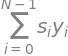

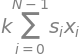

In [ ]:
#N = 2
N = sp.symbols('N', integer=True, positive=True)
a = sp.IndexedBase('a')
b = sp.IndexedBase('b')

x = sp.IndexedBase('x')
y = sp.IndexedBase('y')
z = sp.IndexedBase('z')
s = sp.IndexedBase('s')

#w = sp.MatrixSymbol('w', N, N)
#w = sp.Matrix(sp.symbols('w0:3_0:3'))
w = sp.IndexedBase('w')

i, j = sp.symbols('i j', integer=True)

i = sp.symbols('i', integer=True)
expr = x[i]      # single-index access

#x = sp.MatrixSymbol('x', N, 1)
#w = sp.MatrixSymbol('w', N, 1)
dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
f = sp.Lambda(x, k * x)
#x[0]
display(s)
display(w[0,:])
display(z)
display(y)
display(expr)
display(dot(s, y))
y = f(dot(s, x))
display(y)
y_ = y.subs(N, 2)


display(sp.simplify(y_))



In [80]:
def sdisplay(x, expr):
    x__ = sp.Eq(sp.symbols(x), expr)
    display(x__)


x = sp.IndexedBase('x')
w = sp.IndexedBase('w')
zs = sp.IndexedBase('z^s')
s = sp.IndexedBase('s')
z = sp.IndexedBase('z')
N = sp.symbols('N', integer=True, positive=True)
i, j, k = sp.symbols('i j k', integer=True)


dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
dot_row = sp.Lambda((w, x, i), sp.summation(w[i, j] * x[j], (j, 0, N-1)) )
f = sp.Lambda(x, k * x)

y = dot_row(w, zs, i)

N_ = 2
y_  = y.subs(N, N_)
y_ = y_.subs(N, N_).doit()
sdisplay('y', y_)
pz = f(y)
pz_ = pz.subs(N, N_).doit()
sdisplay('p_z', pz_)
for _i, s_zs in enumerate(S_zs):
    zs_v = s_zs[0]
    d = {zs[i]: zs_v[i] for i in range(zs_v.shape[0])}
    sdisplay('d_'+s_zs[1], d)
    zs_p = pz_.subs(d)    
    sdisplay('p^z_s'+s_zs[1], zs_p)

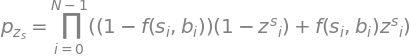

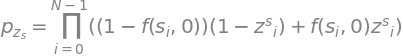

In [121]:
f = sp.Function('f')
idx = sp.Wild('idx')

zs = sp.IndexedBase('z^s')

term = zs[i] * f(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))

p_zs = sp.Product(term, (i, 0, N-1))

zs_v = np.array([1, 0])
d = {zs[i]: zs_v[i] for i in range(zs_v.shape[0])}
p_zs = p_zs.subs(d)
sdisplay('p_{z_s}', p_zs)
p_zs_ = p_zs.replace(lambda a: a.func == f, lambda a: k*(a.args[0] - a.args[1]))
p_zs_ = p_zs.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0))
sdisplay('p_{z_s}', p_zs_)
idx = sp.Wild('idx')
p_zs_ = p_zs_.subs(N, N_).doit()
p_zs_ = p_zs_.subs(b[idx], 0)
#p_zs_ = p_zs_.subs(b[idx], 0).doit()
sdisplay('p_{z_s}', p_zs_)



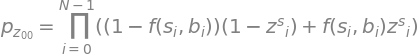

In [ ]:
f = sp.Function('f')
idx = sp.Wild('idx')

zs = sp.IndexedBase('z^s')

term = zs[i] * f(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))

p_zs = sp.Product(term, (i, 0, N-1))

for _i, s_zs in enumerate(S_zs):
    zs_v = s_zs[0]
    __p_zs = f'p_{{z_{{{s_zs[1]}}}}}'
    terms = [
        f(s[i], b[i]) if int(zs_i) == 1 else (1 - f(s[i], b[i]))
        for i, zs_i in enumerate(zs_v)
    ]
    p_zs = sp.Mul(*terms)   # or use sp.prod in recent sympy versions
    sdisplay(__p_zs, p_zs)
    p_zs = p_zs.replace(lambda a: a.func == f, lambda a: k*(a.args[0] - a.args[1]))
    p_zs = p_zs.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0))
    sdisplay(__p_zs, p_zs)



In [106]:
import sympy as sp

# Symbols and indexed bases
b = sp.IndexedBase('b')
s = sp.IndexedBase('s')
k = sp.symbols('k')

# Expression
expr = k**2 * (-b[0] + s[0]) * (-b[1] + s[1])

# Replace ALL b[i]

idx = sp.Wild('idx')
expr2 = expr.subs(b[idx], 0)
expr2 = expr.subs(sp.Indexed(b, idx), 0)
expr2 = expr.replace(
    lambda node: getattr(node, "is_Indexed", False) and node.base == b,
    lambda node: sp.Integer(0)
)

display(expr2)
